In [1]:
import os
import h5py
import numpy as np
import sklearn.metrics


def _compute_refcov(mat):
    with h5py.File(mat, "r") as f:
        leadfield_data = f["leadfield4GEDAI"]
        # ch_names
        leadfield_channel_data = leadfield_data["electrodes"]
        leadfield_ch_names = [
            f[ref[0]][()].tobytes().decode("utf-16le").lower()
            for ref in leadfield_channel_data["Name"]
        ]
        # leadfield matrix
        leadfield_gain_matrix = leadfield_data["gram_matrix_avref"]
        leadfield_gain_matrix = np.array(leadfield_gain_matrix).T

        return (leadfield_gain_matrix, leadfield_ch_names)


mat = os.path.abspath("gedai/data/fsavLEADFIELD_4_GEDAI.mat")

leadfield_gain_matrix, leadfield_ch_names = _compute_refcov(mat)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'c:\Users\victor.ferat\Documents\Github\gedai\gedai\data\fsavLEADFIELD_4_GEDAI.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import mne
cov = mne.Covariance(data=leadfield_gain_matrix, names=leadfield_ch_names, bads=[], projs=[], nfree=0)
cov.save("gedai/data/fsavLEADFIELD_4_GEDAI-cov.fif", overwrite=True)

Overwriting existing file.
Overwriting existing file.


In [2]:
import mne
cov = mne.read_cov("gedai/data/fsavLEADFIELD_4_GEDAI-cov.fif")
cov.data

    343 x 343 full covariance (kind = 1) found.


array([[211445.51956533, 203627.13517374, 179207.40685434, ...,
         46161.24641791,  81541.38225979,  62601.30358432],
       [203627.13517374, 217740.51155493, 204890.52680889, ...,
         44272.33593595,  63394.31624565,  62335.98240826],
       [179207.40685434, 204890.52680889, 212561.69979064, ...,
         61993.43555224,  63328.37347126,  79972.56331383],
       ...,
       [ 46161.24641791,  44272.33593595,  61993.43555224, ...,
        186070.80794079, 134148.19067043, 179981.34245703],
       [ 81541.38225979,  63394.31624565,  63328.37347126, ...,
        134148.19067043, 175405.84685218, 134079.62220867],
       [ 62601.30358432,  62335.98240826,  79972.56331383, ...,
        179981.34245703, 134079.62220867, 177887.20703003]],
      shape=(343, 343))

In [11]:
raw = mne.io.RawArray(np.random.randn(len(cov.ch_names), 1), mne.create_info(cov.ch_names, sfreq=1, ch_types="eeg"))
raw.set_montage("standard_1005", match_case=False)

Creating RawArray with float64 data, n_channels=343, n_times=1
    Range : 0 ... 0 =      0.000 ...     0.000 secs
Ready.


<RawArray | 343 x 1 (1.0 s), ~389 KiB, data loaded>

In [16]:
from gedai.gedai.covariances import _compute_distance_cov

distance_cov = _compute_distance_cov(raw)

n_channels = distance_cov.shape[0]
projection_matrix = np.eye(n_channels) - np.ones((n_channels, n_channels)) / n_channels

# Apply average reference to the distance covariance
distance_cov_avref = projection_matrix @ distance_cov @ projection_matrix.T

In [18]:
distance_cov = mne.Covariance(data=distance_cov_avref, names=cov.ch_names, bads=[], projs=[], nfree=0)

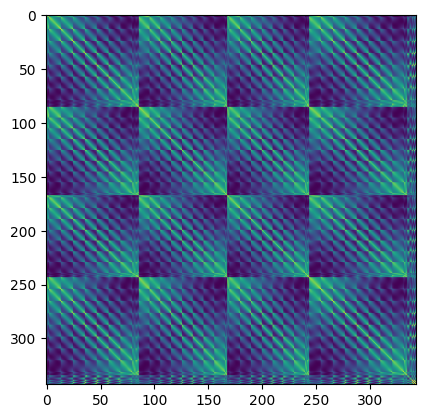

In [17]:
import matplotlib.pyplot as plt

plt.imshow(distance_cov_avref.data, cmap="viridis")

In [21]:
import matplotlib.pyplot as plt
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf

from gedai import Gedai
from gedai.viz import plot_mne_style_overlay_interactive

# %% Load sample EEG data
subjects = [1]
runs = [4, 8, 12]
raw_fnames = eegbci.load_data(subjects, runs, update_path=True)
raws = [read_raw_edf(f, preload=True) for f in raw_fnames]
# Concatenate runs from the same subject
raw = concatenate_raws(raws)
# Make channel names follow standard conventions
eegbci.standardize(raw)

# Crop to the first 15 seconds for demonstration purposes
raw.crop(0, 15)
raw.pick("eeg").load_data().apply_proj()


gedai_broadband = Gedai()
gedai_broadband.fit_raw(raw, noise_multiplier=6.0, reference_cov=distance_cov)
raw_broadband_corrected = gedai_broadband.transform_raw(raw, verbose=False)

gedai_spectral = Gedai(wavelet_type="haar", wavelet_level=5, wavelet_low_cutoff=2, reference_cov=distance_cov)
gedai_spectral.fit_raw(raw_broadband_corrected, noise_multiplier=3.0)
raw_spectral_corrected = gedai_spectral.transform_raw(
    raw_broadband_corrected, verbose=False
)

plot_mne_style_overlay_interactive(raw, raw_spectral_corrected)

Extracting EDF parameters from C:\Users\victor.ferat\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\victor.ferat\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\victor.ferat\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
No projector specified for this dataset. Please consider the method self.add_proj.
Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 29 events and 160 original time points ...
0 bad epochs d

TypeError: Gedai.__init__() got an unexpected keyword argument 'reference_cov'